
**Análisis de Movilidad Urbana** | [Repositorio en GitHub](https://github.com/Edvard-Pichardo/movilidad-urbana-analisis)

Este notebook complementa la base de datos MySQL del **Sistema de Análisis de Movilidad Urbana y Transporte**. Aquí recrearemos las 5 consultas analíticas utilizando **pandas**, **matplotlib** y **seaborn**, partiendo de archivos CSV exportados de la base de datos original.

In [1]:
#Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Configuramos estilo de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 3)

In [3]:
!git clone https://github.com/Edvard-Pichardo/movilidad-urbana-analisis.git
RUTA_BASE = 'movilidad-urbana-analisis/data/'

Cloning into 'movilidad-urbana-analisis'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 120 (delta 56), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 971.61 KiB | 6.89 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [4]:
!ls movilidad-urbana-analisis/data/

demanda_horaria.csv  velocidad_viajes.csv      viajes_por_hora.csv
gasto_cliente.csv    viajes_conductor_mes.csv


In [5]:
#Cargamos cada archivo en un DataFrame
df_horas       = pd.read_csv(RUTA_BASE + 'viajes_por_hora.csv')
df_cond_mes    = pd.read_csv(RUTA_BASE + 'viajes_conductor_mes.csv')
df_gasto_cli   = pd.read_csv(RUTA_BASE + 'gasto_cliente.csv')
df_velocidades = pd.read_csv(RUTA_BASE + 'velocidad_viajes.csv')
df_demanda     = pd.read_csv(RUTA_BASE + 'demanda_horaria.csv')

#Verificamos que se leyeron correctamente
print('Horas:', df_horas.shape)
print('Conductores mensuales:', df_cond_mes.shape)
print('Clientes:', df_gasto_cli.shape)
print('Velocidades:', df_velocidades.shape)
print('Demanda horaria:', df_demanda.shape)

Horas: (24, 2)
Conductores mensuales: (36, 4)
Clientes: (50, 3)
Velocidades: (22234, 4)
Demanda horaria: (2919, 6)


### Horas de mayor afluencia con ranking

Identificamos las horas del día con más viajes completados y las ordenamos con un ranking. Esto permite conocer las horas pico para planificar la flota y estrategias de precios dinámicos.

In [6]:
#Ordenamos el DataFrame (aunque ya viene ordenado del SQL)
df_horas = df_horas.sort_values('total_viajes', ascending=False)
df_horas['ranking'] = range(1, len(df_horas)+1)

#Mostramos las 10 primeras horas
df_horas.head(10)

,hora,total_viajes,ranking
0,18,1630,1
1,19,1617,2
2,17,1616,3
3,9,1609,4
4,8,1595,5
5,7,1589,6
6,21,1003,7
7,15,996,8
8,12,995,9
9,16,994,10


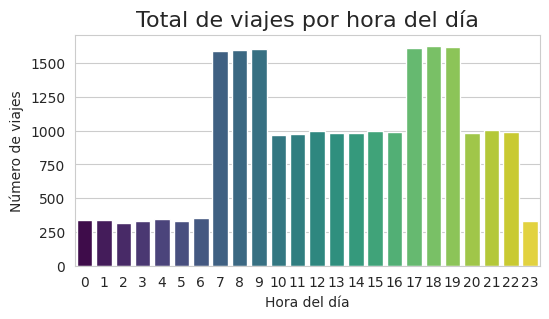

In [7]:
#Gráfico de barras de todas las horas
plt.figure(figsize=(6,3))
sns.barplot(data=df_horas, x='hora', y='total_viajes', hue='hora', palette='viridis', legend=False)
plt.title('Total de viajes por hora del día', fontsize=16)
plt.xlabel('Hora del día'), plt.ylabel('Número de viajes')
plt.xticks(rotation=0)
plt.show()

Las barras más altas muestran las horas pico. Generalmente, se observan picos alrededor de las 8-9 AM y 5-7 PM que, para este caso, es correcto, debido a que la base de datos fue generada de esa manera.

### Conductores con caída intermensual > 5%

Calculamos para cada conductor la variación porcentual de viajes entre un mes y el siguiente. Filtramos aquellos que disminuyeron más del 5%, señal de posible abandono.

In [8]:
#Creamos la columna de viajes del mes anterior usando shift()

#Primero nos aseguramos de que esté ordenado por conductor y mes
df_cond_mes = df_cond_mes.sort_values(['id_conductor', 'mes'])
df_cond_mes['viajes_anterior'] = df_cond_mes.groupby('id_conductor')['viajes'].shift(1)

#Calculamos el cambio porcentual
df_cond_mes['cambio_pct'] = (df_cond_mes['viajes'] - df_cond_mes['viajes_anterior']) / df_cond_mes['viajes_anterior'] * 100

#Filtramos caídas > 5% (cambio_pct < -5) y con mes anterior válido
caidas = df_cond_mes[(df_cond_mes['cambio_pct'] < -5) & df_cond_mes['viajes_anterior'].notna()]

#Mostramos los casos encontrados
caidas[['nombre_conductor', 'mes', 'viajes', 'viajes_anterior', 'cambio_pct']].head(10)

,nombre_conductor,mes,viajes,viajes_anterior,cambio_pct
10,Oscar Martínez,2026-08,444,484.0,-8.264463
21,Carlos Morales,2026-07,459,496.0,-7.459677
23,Carlos Morales,2026-09,448,489.0,-8.384458
35,Carmen Ozuna,2026-09,462,498.0,-7.228916


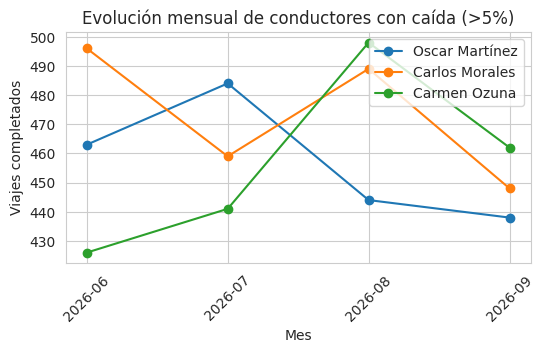

In [19]:
#Visualizamos la evolución mensual de los conductores con caída
cond_list = caidas['id_conductor'].unique()
for cond in cond_list[:5]:  #primeros 5 para no saturar
    subset = df_cond_mes[df_cond_mes['id_conductor'] == cond]
    plt.plot(subset['mes'], subset['viajes'], marker='o', label=subset['nombre_conductor'].iloc[0])
plt.title('Evolución mensual de conductores con caída (>5%)')
plt.xlabel('Mes'), plt.ylabel('Viajes completados')
plt.legend(), plt.xticks(rotation=45)
plt.show()

Los conductores que aparecen aquí podrían necesitar alguna clase de intervención (incentivos, contacto por parte de la empresa) para evitar la pérdida de talento.

### Segmentación de clientes de alto valor

Dividimos a los clientes en cuartiles según su gasto total. Nos enfocamos en el cuartil superior (top 25%), los que llamamos clientes VIP.

In [10]:
#Calculamos cuartiles
df_gasto_cli['cuartil'] = pd.qcut(df_gasto_cli['total_gastado'], q=4, labels=['Cuartil 4 (bajo)', 'Cuartil 3', 'Cuartil 2', 'Cuartil 1 (alto)'])

#Contamos cuántos clientes hay en cada segmento
print(df_gasto_cli['cuartil'].value_counts())

#Filtramos los VIP
vip = df_gasto_cli[df_gasto_cli['cuartil'] == 'Cuartil 1 (alto)']
vip.head(10)

cuartil
Cuartil 4 (bajo)    13
Cuartil 1 (alto)    13
Cuartil 3           12
Cuartil 2           12
Name: count, dtype: int64


,id_cliente,nombre_cliente,total_gastado,cuartil
0,19,Cliente19 Apellido,20202.55,Cuartil 1 (alto)
1,35,Cliente35 Apellido,19930.46,Cuartil 1 (alto)
2,46,Cliente46 Apellido,19800.50,Cuartil 1 (alto)
3,41,Cliente41 Apellido,19657.60,Cuartil 1 (alto)
4,8,Cliente8 Apellido,19631.18,Cuartil 1 (alto)
5,28,Cliente28 Apellido,19623.99,Cuartil 1 (alto)
6,18,Cliente18 Apellido,19499.64,Cuartil 1 (alto)
7,44,Cliente44 Apellido,19405.03,Cuartil 1 (alto)
8,22,Cliente22 Apellido,19394.42,Cuartil 1 (alto)
9,16,Cliente16 Apellido,19254.14,Cuartil 1 (alto)


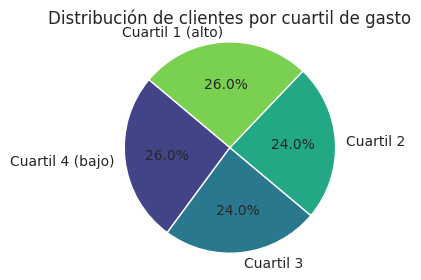

In [11]:
#Gráfico de pastel con la distribución de clientes por cuartil
cuenta_cuartiles = df_gasto_cli['cuartil'].value_counts().sort_index()
plt.figure(figsize=(3,3))
plt.pie(cuenta_cuartiles, labels=cuenta_cuartiles.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 4))
plt.title('Distribución de clientes por cuartil de gasto'), plt.axis('equal')
plt.show()

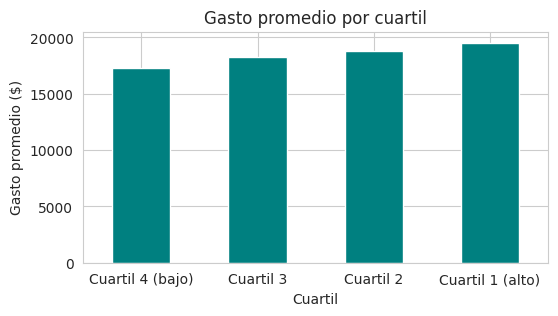

In [12]:
#También podemos ver el gasto promedio por cuartil
df_gasto_cli.groupby('cuartil', observed=False)['total_gastado'].mean().plot(kind='bar', color='teal')
plt.title('Gasto promedio por cuartil')
plt.xlabel('Cuartil'), plt.ylabel('Gasto promedio ($)')
plt.xticks(rotation=0)
plt.show()

El cuartil superior concentra una gran parte del gasto total. Estos clientes son candidatos para un programa de fidelización, aunque, como vemos en el último grpafico, no hay una diferencia significativa entre los cuartiles. Esto se debe a cómo generamos nuestros datos en la base de datos.

### Detección de viajes con velocidad anómala

Buscamos viajes cuya velocidad promedio supere la media más 2 desviaciones estándar. Estos outliers pueden señalar errores en los datos o comportamientos inusuales.

In [13]:
#Calculamos media y desviación estándar de la velocidad
media = df_velocidades['velocidad_kmh'].mean()
desv  = df_velocidades['velocidad_kmh'].std()
umbral = media + 2 * desv

print(f'Media de velocidad: {media:.2f} km/h')
print(f'Desviación estándar: {desv:.2f} km/h')
print(f'Umbral de anomalía (media+2σ): {umbral:.2f} km/h')

#Filtramos viajes atípicos
atipicos = df_velocidades[df_velocidades['velocidad_kmh'] > umbral]
print(f'Cantidad de viajes atípicos: {len(atipicos)}')
atipicos.head()

Media de velocidad: 37.59 km/h
Desviación estándar: 7.22 km/h
Umbral de anomalía (media+2σ): 52.04 km/h
Cantidad de viajes atípicos: 0


,id_viaje,distancia_km,duracion_min,velocidad_kmh


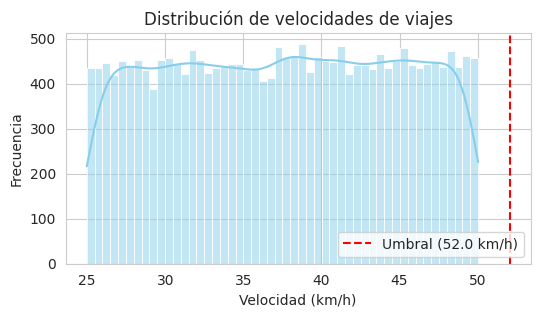

In [14]:
#Histograma de velocidades y línea de corte
plt.figure(figsize=(6,3))
sns.histplot(df_velocidades['velocidad_kmh'], bins=50, kde=True, color='skyblue')
plt.axvline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral:.1f} km/h)')
plt.title('Distribución de velocidades de viajes')
plt.xlabel('Velocidad (km/h)'), plt.ylabel('Frecuencia')
plt.legend()
plt.show()

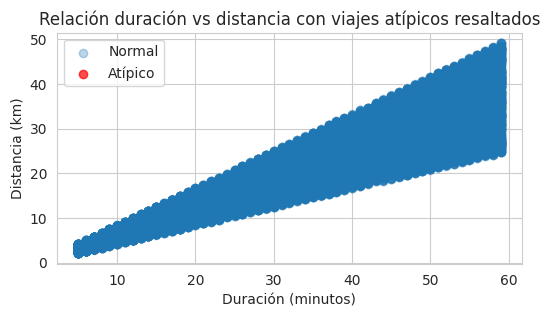

In [15]:
#Distancia vs duración
plt.figure(figsize=(6,3))
plt.scatter(df_velocidades['duracion_min'], df_velocidades['distancia_km'], alpha=0.3, label='Normal')
plt.scatter(atipicos['duracion_min'], atipicos['distancia_km'], color='red', alpha=0.7, label='Atípico')
plt.xlabel('Duración (minutos)'), plt.ylabel('Distancia (km)')
plt.title('Relación duración vs distancia con viajes atípicos resaltados')
plt.legend()
plt.show()

Si hubiera algún viaje atípico se marcaría con un punto rojo, lo que indicaría los viajes donde la distancia recorrida es inusualmente alta para el tiempo empleado, lo que sugiere datos erróneos o un posible fraude.

### Creación de un dataset de series temporales

Construimos un conjunto de características temporales pensado para predecir la demanda (`num_viajes`) en la próxima hora. Añadimos la variable `viajes_hora_anterior` como predictor básico.

In [16]:
#Ordenamos cronológicamente
df_demanda = df_demanda.sort_values(['fecha', 'hora'])

#Creamos la columna de viajes de la hora anterior
df_demanda['viajes_hora_anterior'] = df_demanda['num_viajes'].shift(1)

#Eliminamos la primera fila (sin hora anterior)
df_ts = df_demanda.dropna(subset=['viajes_hora_anterior']).copy()

#Mostramos las primeras filas del dataset
df_ts[['fecha', 'hora', 'dia_semana', 'num_viajes', 'viajes_hora_anterior', 'tarifa_promedio', 'conductores_unicos']].head()

,fecha,hora,dia_semana,num_viajes,viajes_hora_anterior,tarifa_promedio,conductores_unicos
1,2026-06-01,1,2,3,4.0,25.31,3
2,2026-06-01,2,2,5,3.0,48.01,4
3,2026-06-01,3,2,5,5.0,33.40,4
4,2026-06-01,4,2,3,5.0,42.11,3
5,2026-06-01,5,2,3,3.0,35.89,3


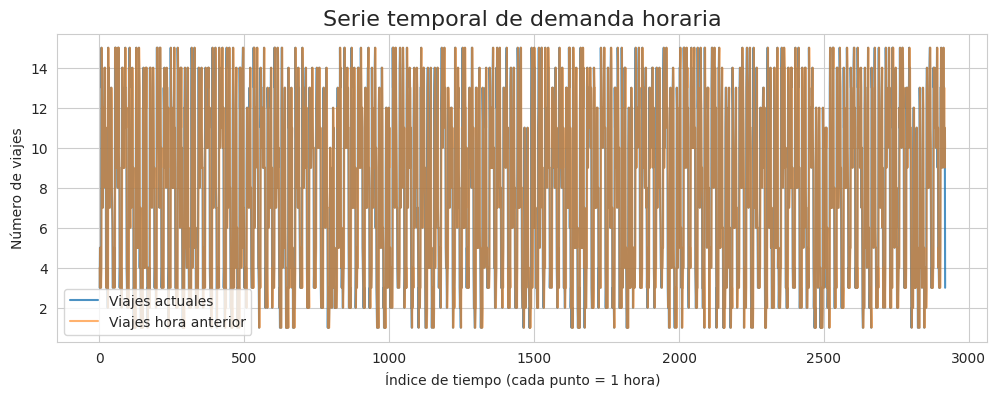

In [17]:
#Visualización de la serie temporal completa (viajes por hora)
plt.figure(figsize=(12,4))
plt.plot(df_ts.index, df_ts['num_viajes'], label='Viajes actuales', alpha=0.8)
plt.plot(df_ts.index, df_ts['viajes_hora_anterior'], label='Viajes hora anterior', alpha=0.6)
plt.title('Serie temporal de demanda horaria', fontsize=16)
plt.xlabel('Índice de tiempo (cada punto = 1 hora)'), plt.ylabel('Número de viajes')
plt.legend()
plt.show()

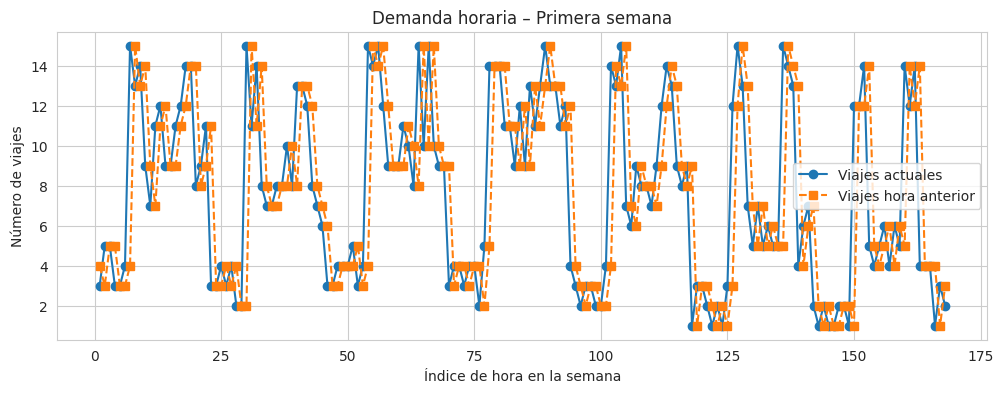

In [18]:
#Zoom a una semana para apreciar el patrón diario
una_semana = df_ts.iloc[0:168]  #primeras 168 horas = 7 días
plt.figure(figsize=(12,4))
plt.plot(una_semana.index, una_semana['num_viajes'], marker='o', linestyle='-', label='Viajes actuales')
plt.plot(una_semana.index, una_semana['viajes_hora_anterior'], marker='s', linestyle='--', label='Viajes hora anterior')
plt.title('Demanda horaria – Primera semana')
plt.xlabel('Índice de hora en la semana'), plt.ylabel('Número de viajes')
plt.legend()
plt.show()

La variable `viajes_hora_anterior` sigue de cerca a la demanda actual, lo que la convierte en un predictor fuerte. Un modelo simple de regresión o LSTM podría usar esta característica junto con `hora` y `dia_semana` para pronosticar la próxima hora.